In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

from preprocessing.PP_Processor import DataCollector
from preprocessing.SignalNoise_Process import SignalProcessor
from preprocessing.PP_Plots import Plotter
from preprocessing.TTM_lifetime import LifetimeFitter

import math
import re

In [2]:
from utils.paths import DESCRIPTORS_DIR,DATABASE_DIR,RAW_DIR

In [3]:
dc = DataCollector()
pl = Plotter()
sp = SignalProcessor()

In [4]:
df_compo = pd.read_excel(RAW_DIR/'1_Ternary_exp.xlsx',sheet_name='composition')
com_Cu = df_compo.sort_values("Cu",ascending=False)['Cu'].to_numpy()
com_Ni = df_compo.sort_values("Ni",ascending=False)['Ni'].to_numpy()
com_Al = df_compo.sort_values("Al",ascending=False)['Al'].to_numpy()

In [5]:
df_compo = df_compo.copy()
df_compo = df_compo.dropna()

df_compo['Cu'] = (df_compo["Cu"] * 100).round(2)
df_compo['Ni'] = (df_compo["Ni"] * 100).round(2)
df_compo['Al'] = (df_compo["Al"] * 100).round(2)

df_compo["symbol"] = (
    "Cu" + df_compo["Cu"].astype(str) +
    " Ni" + df_compo["Ni"].astype(str) +
    " Al" + df_compo["Al"].astype(str)
)

In [6]:
FOLDER = RAW_DIR/"_1st_bad_data_no_removed"
files_index, selected = dc.extract_file_names(FOLDER, pattern= re.compile(
    r"""
    sample(?P<sample>\d+)       # sample12
    .*?                         # anything in between (important!)
    pump_                       # pump_
    (?P<power>\d+)p0mW          # 10p0mW → captures 10
    """,
    
    re.VERBOSE
),select_power=8)

In [7]:
selected

,file,sample,power_mW,path
6,sample1_1p5um_pump_8p0mW_norm_transmission_dT_...,1,8,/Users/linarojas/Desktop/Research/Papers/Combi...
27,sample2_1p5um_pump_8p0mW_norm_transmission_dT_...,2,8,/Users/linarojas/Desktop/Research/Papers/Combi...
24,sample3_1p5um_pump_8p0mW_norm_transmission_dT_...,3,8,/Users/linarojas/Desktop/Research/Papers/Combi...
41,sample4_1p5um_pump_8p0mW_norm_transmission_dT_...,4,8,/Users/linarojas/Desktop/Research/Papers/Combi...
8,sample5_1p5um_pump_8p0mW_norm_transmission_dT_...,5,8,/Users/linarojas/Desktop/Research/Papers/Combi...
30,sample6_1p5um_pump_8p0mW_norm_transmission_dT_...,6,8,/Users/linarojas/Desktop/Research/Papers/Combi...
19,sample7_1p5um_pump_8p0mW_norm_transmission_dT_...,7,8,/Users/linarojas/Desktop/Research/Papers/Combi...
13,sample8_1p5um_pump_8p0mW_norm_transmission_dT_...,8,8,/Users/linarojas/Desktop/Research/Papers/Combi...
37,sample9_1p5um_pump_8p0mW_norm_transmission_dT_...,9,8,/Users/linarojas/Desktop/Research/Papers/Combi...
36,sample10_1p5um_pump_8p0mW_norm_transmission_dT...,10,8,/Users/linarojas/Desktop/Research/Papers/Combi...


Substrate data

In [7]:
FOLDER = RAW_DIR/"_1st_bad_data_no_removed"
files_index_sub, selected_sub = dc.extract_file_names(FOLDER, pattern= re.compile(
    r"""
    substrate_spot(?P<sample>\d+)       # sample12
    .*?                         # anything in between (important!)
    pump_                       # pump_
    (?P<power>\d+)p0mW          # 10p0mW → captures 10
    """,
    
    re.VERBOSE
),select_power=8)

In [8]:
master_wvl = dc.build_master(selected, smooth="wvl", method="savgol", savgol_window=51, savgol_poly=3)
master_time = dc.build_master(selected, smooth="time", method="gaussian", gaussian_sigma=3)
master_time_sub = dc.build_master(selected_sub, smooth="time", method="gaussian", gaussian_sigma=3)

In [19]:
df = master_wvl[12]
df = df.drop(columns=["sample", "power_mW"])

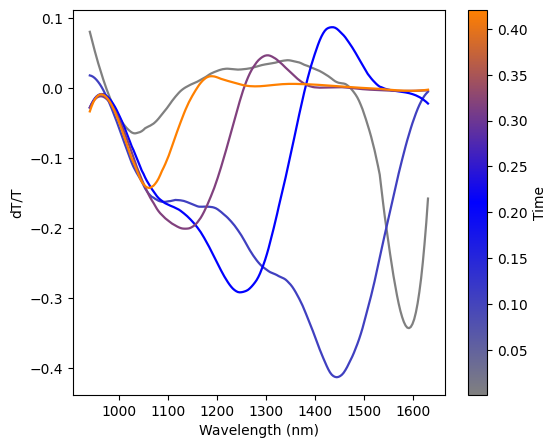

In [20]:
pl.plot_spectra_at_times(
    df, time_range=(0, 0.5), step=3,
    legend=False,figsize=(6,5)
)
plt.show()

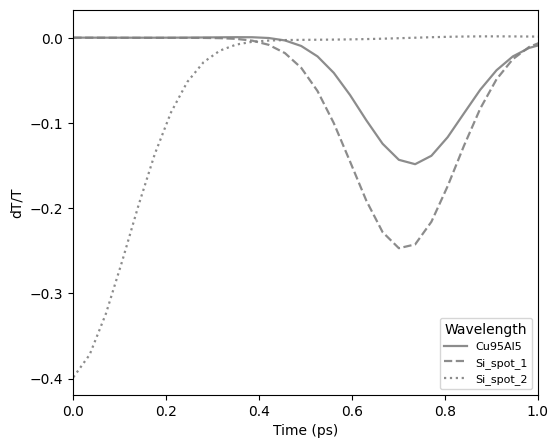

In [9]:
df_k = master_time[2]
df_s = master_time_sub[1]
df_s_2 = master_time_sub[2]

df_k = df_k.drop(columns=["sample", "power_mW"])
df_s = df_s.drop(columns=["sample", "power_mW"])
df_s_2 = df_s_2.drop(columns=["sample", "power_mW"])

fig, ax = plt.subplots(figsize=(6,5))

pl.kinetic_plot(
    df_k,
    wavelengths=[1550],
    xlim=[0,1],
    linestyle='-',
    ax=ax,
    legend=False,
    label='Cu95Al5',
    add_colorbar=False
)

pl.kinetic_plot(
    df_s,
    wavelengths=[1550],
    xlim=[0,1],
    linestyle='--',
    ax=ax,
    legend=True,
    label='Si_spot_1',
    add_colorbar=False
)

pl.kinetic_plot(
    df_s_2,
    wavelengths=[1550],
    xlim=[0,1],
    linestyle=':',
    ax=ax,
    legend=True,
    label='Si_spot_2',
    add_colorbar=False
)

plt.show()

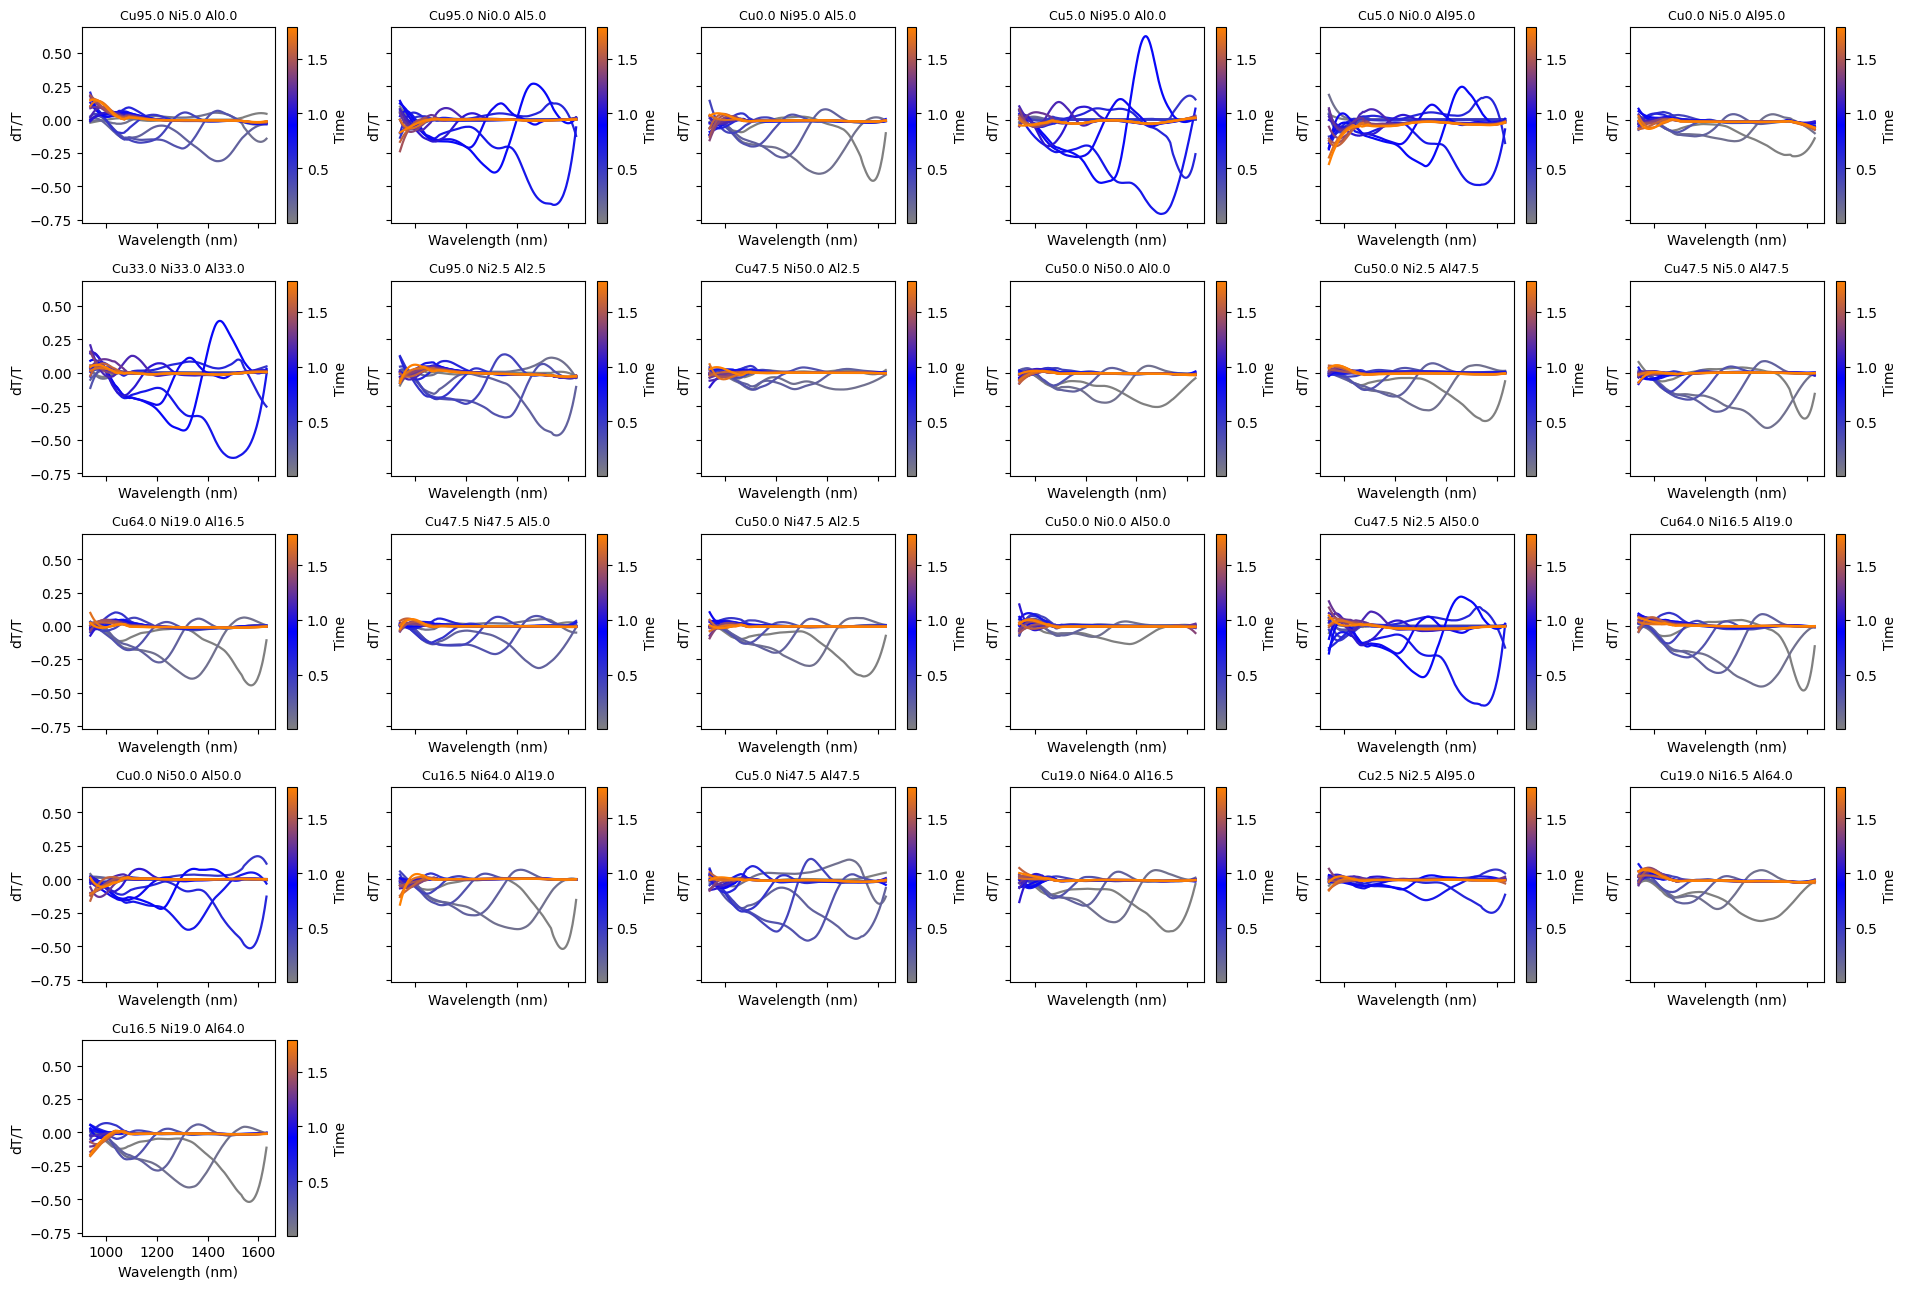

In [16]:
sample_data = np.array(list(master_wvl.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()

for ax, sample in zip(axes, sample_data):
    df = master_wvl[sample].drop(columns=["sample", "power_mW"])

    pl.plot_spectra_at_times(
        df,
        time_range=(0, 2),
        step=3,
        legend=False,
        ax=ax,         
        add_colorbar=True,
        figsize=(6,5)  
    )
    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Kinetic Plot

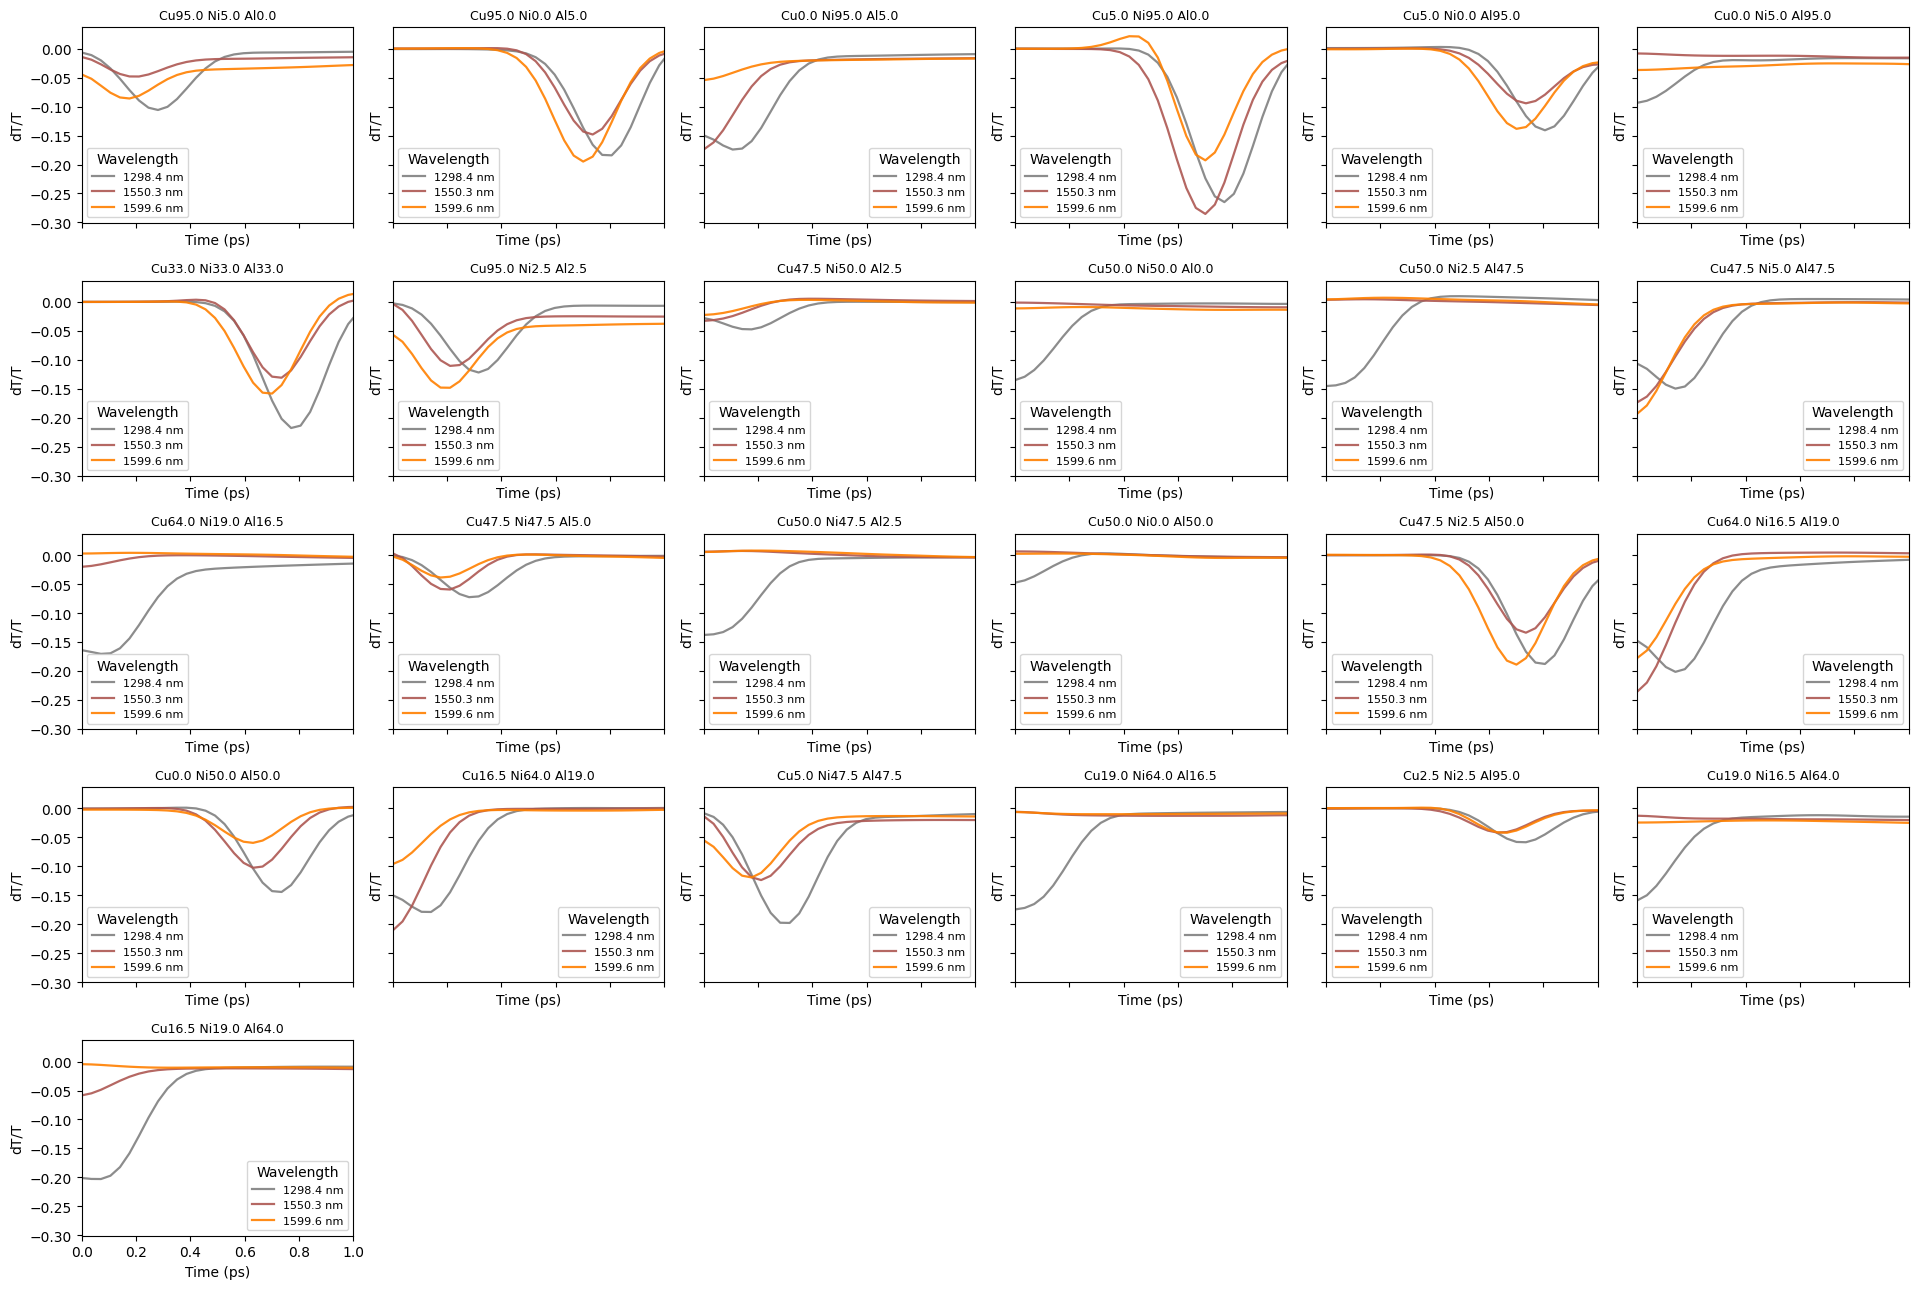

In [14]:
sample_data = np.array(list(master_time.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to 1D list of axes

for ax, sample in zip(axes, sample_data):
    df = master_time[sample]
    df = df.drop(columns=['sample', 'power_mW'])
    pl.kinetic_plot(df,wavelengths = [1300, 1550, 1600],xlim=(0, 1),ax=ax,legend=True,add_colorbar=False )
    
    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)


for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

In [11]:
df_sub = next(iter(master_time_sub.values())).copy()
df_sub = df_sub.drop(columns=["sample", "power_mW"], errors="ignore")

In [14]:
master_time_sub.keys()

dict_keys([1, 2])

In [12]:
df_sub

,0.001,0.036,0.071,0.106,0.141,0.176,0.211,0.246,0.281,0.316,...,20.786,22.786,24.786,26.786,28.786,30.786,32.786,34.786,36.786,38.786
0.00000E+0,,,,,,,,,,,,,,,,,,,,,
939.9,0.024325,0.021754,0.016895,0.010300,0.002746,-0.004857,-0.011599,-0.016729,-0.019797,-0.020769,...,0.048521,0.070680,0.090723,0.107341,0.119293,0.125856,0.127289,0.125036,0.121419,0.118845
943.4,0.013627,0.015517,0.019124,0.024056,0.029649,0.034939,0.038738,0.039819,0.037156,0.030121,...,0.206235,0.232955,0.251866,0.260543,0.257860,0.244768,0.224451,0.201833,0.182524,0.171431
946.8,0.028015,0.028786,0.029465,0.028761,0.025593,0.019632,0.011448,0.002200,-0.006941,-0.015329,...,0.110571,0.125489,0.136458,0.143201,0.145114,0.141837,0.133992,0.123601,0.113808,0.107873
950.2,0.059717,0.060051,0.060439,0.060281,0.058656,0.054423,0.046465,0.033983,0.016749,-0.004766,...,0.162048,0.174728,0.178755,0.174130,0.161605,0.142864,0.120670,0.098717,0.081061,0.071210
953.6,0.017787,0.015280,0.011069,0.006570,0.003429,0.002976,0.005701,0.011013,0.017412,0.023025,...,-0.080278,-0.080162,-0.080410,-0.081087,-0.082033,-0.082974,-0.083662,-0.084001,-0.084069,-0.084035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617.3,-0.000491,-0.000516,-0.000552,-0.000574,-0.000551,-0.000443,-0.000211,0.000236,0.001015,0.002216,...,0.009462,0.009517,0.009499,0.009429,0.009332,0.009228,0.009130,0.009044,0.008980,0.008944
1620.8,-0.000478,-0.000511,-0.000564,-0.000616,-0.000640,-0.000598,-0.000451,-0.000118,0.000494,0.001427,...,0.009320,0.009352,0.009323,0.009257,0.009178,0.009099,0.009026,0.008964,0.008915,0.008888
1624.3,0.003030,0.003440,0.004209,0.005226,0.006306,0.007161,0.007415,0.006673,0.004661,0.001379,...,-0.086616,-0.089909,-0.094305,-0.098346,-0.100395,-0.099392,-0.095392,-0.089630,-0.084078,-0.080696


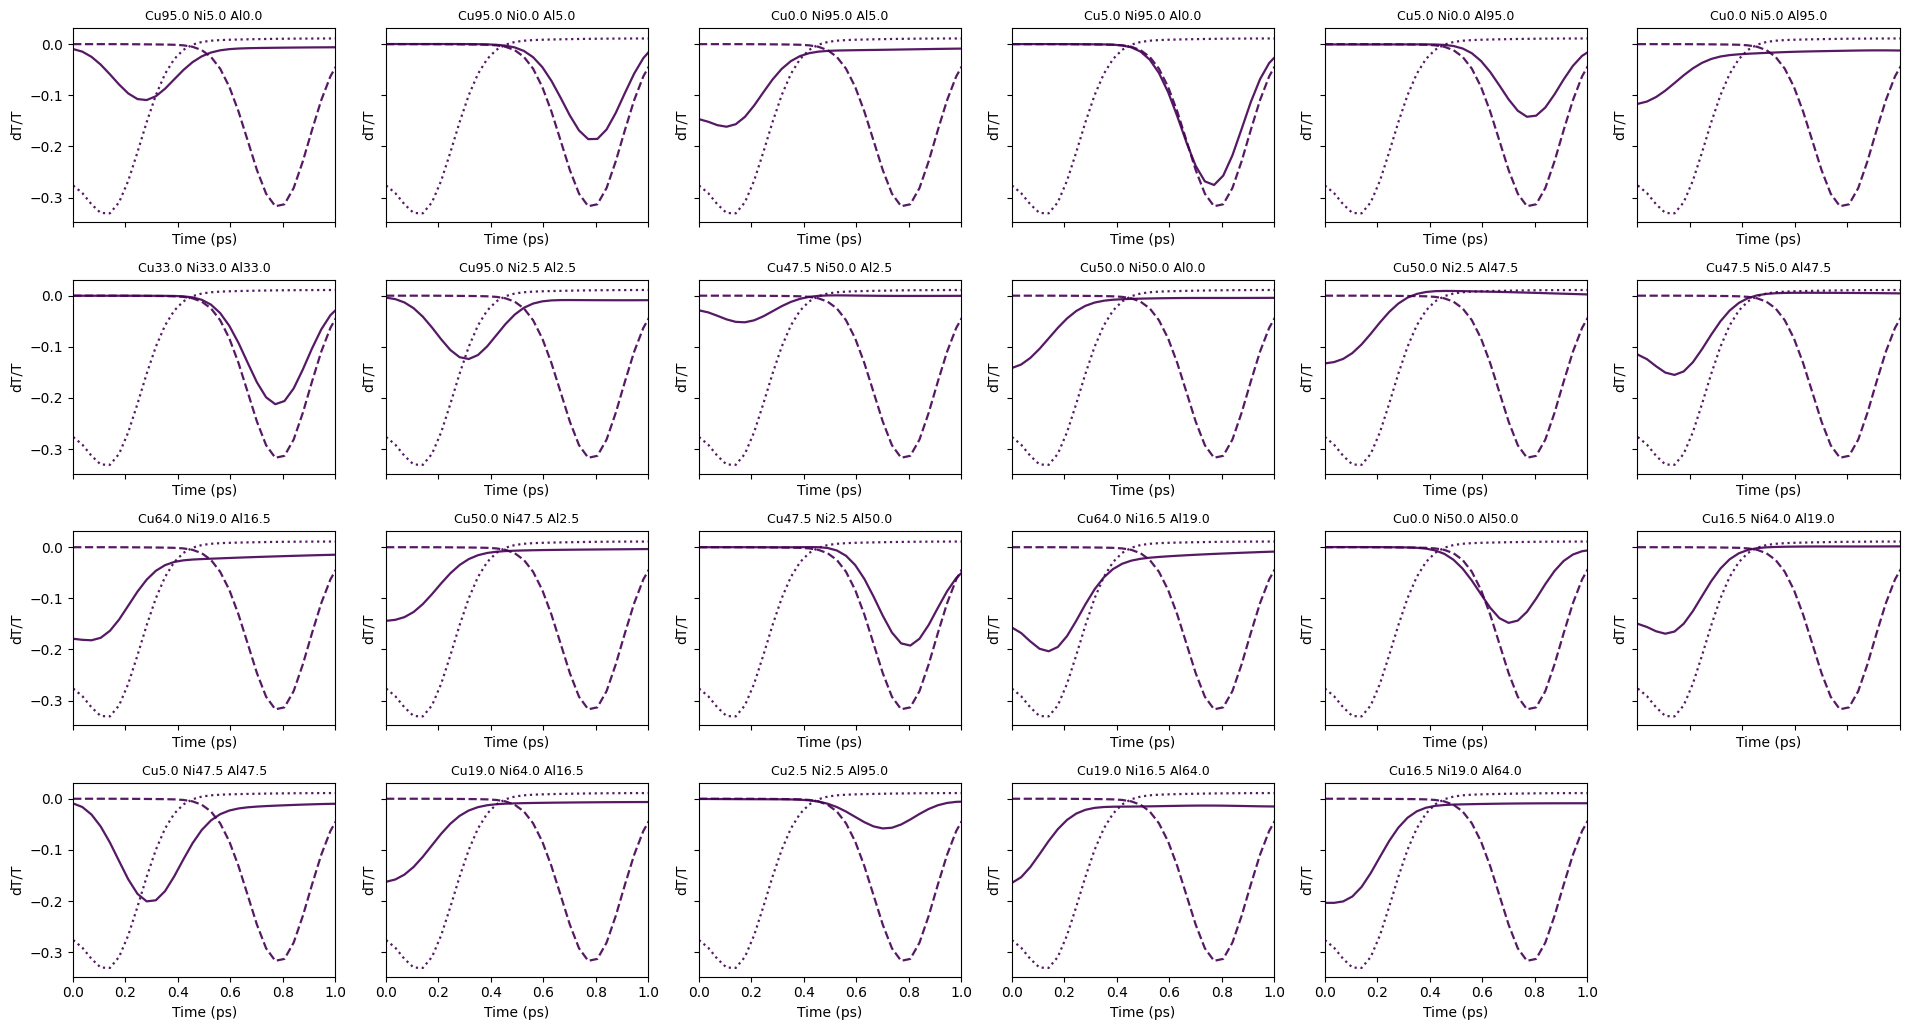

In [12]:
sample_data = np.array(list(master_time.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()

df_sub = df_sub = master_time_sub[1].copy()
df_sub = df_sub.drop(columns=["sample", "power_mW"], errors="ignore")

df_sub_2 = master_time_sub[2].copy()
df_sub_2 = df_sub_2.drop(columns=["sample", "power_mW"], errors="ignore")

for ax, sample in zip(axes, sample_data):
    df = master_time[sample].copy()
    df = df.drop(columns=["sample", "power_mW"], errors="ignore")

    pl.kinetic_plot(
        df,
        wavelengths=[1320],
        xlim=(0, 1),
        ax=ax,
        legend=False,
        add_colorbar=False,
        cmap_colors = ((68, 1, 84), (59, 82, 139), (253, 231, 37))
    )

    pl.kinetic_plot(
        df_sub,
        wavelengths=[1320],
        xlim=(0, 1),
        ax=ax,
        legend=False,
        add_colorbar=False,
        linestyle="--",
         cmap_colors = ((68, 1, 84), (59, 82, 139), (253, 231, 37))
    )
    
    pl.kinetic_plot(
        df_sub_2,
        wavelengths=[1320],
        xlim=(0, 1),
        ax=ax,
        legend=False,
        add_colorbar=False,
        linestyle=":",
         cmap_colors = ((68, 1, 84), (59, 82, 139), (253, 231, 37))
    )

    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Lifetime calculation

In [21]:
lt = LifetimeFitter()

In [55]:
wvl = 1300

df = master_time[6]
columns = ['sample','power_mW']
df = df.drop(columns=columns)

x = df.columns.to_numpy()
idx = np.abs(df.index.to_numpy(dtype=float) - wvl).argmin()

y = df.iloc[idx].to_numpy(dtype=float)

lifetime = lt.fit(time=x, y_exp=y)


lifetime = {}
wvl = 1308.8

for key, df in master_dfs.items():
    df = df.drop(columns=['sample', 'power_mW'])


    x = df.columns.to_numpy()

    idx = np.abs(df.index.to_numpy(dtype=float) - wvl).argmin()
    y = df.iloc[idx].to_numpy(dtype=float)

    lifetime[key] = lt.fit(time=x, y_exp=y)

In [32]:

def plot_lifetime_fit(
    lifetime: dict,
    #key,
    time,
    y_exp,
    time_range=None,          # NEW: (tmin, tmax)
    figsize=(6, 4),
):
    """
    Plot experimental data vs fitted curve for a given key,
    optionally restricting to a time range.
    """

    fit_out = lifetime
    y_fit = fit_out["y_fit"]
    r2 = fit_out.get("r2", None)

    time = np.asarray(time, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)

    if time_range is not None:
        tmin, tmax = time_range
        mask = (time >= tmin) & (time <= tmax)
    else:
        mask = slice(None)

    plt.figure(figsize=figsize)
    plt.plot(time[mask], y_exp[mask], "o", label="exp")

    if r2 is not None:
        plt.plot(time[mask], y_fit[mask], "-", label=f"fit (R² = {r2:.3f})")
    else:
        plt.plot(time[mask], y_fit[mask], "-", label="fit")

    if time_range is not None:
        plt.xlim(time_range)

    plt.xlabel("Time (ps)")
    plt.ylabel("dT/T")
    plt.legend()
    plt.tight_layout()
    plt.show()

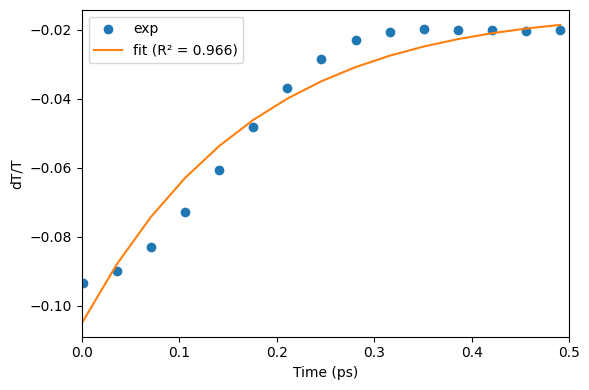

In [76]:
plot_lifetime_fit(
    lifetime=lifetime,
    time=x,
    y_exp=y,
    time_range=(0, 0.5),
)

Lifetime equation fitting
1. Functions of the equation and the objective function
2. Find initial guesses
3. Gradient-based search to find the minimum

In [79]:
PATH_TEST = RAW_DIR / 'TTM_Test_Data.xlsx'
df_test = pd.read_excel(PATH_TEST,sheet_name='Au50Pd50')

df_test.head(5)
y_exp = df_test['dT/T exp'].to_numpy()
time_sara = df_test['time (ps)'].to_numpy()
y_fit_sara = df_test['dT/T Fit'].to_numpy()

In [82]:
lifetim_sara = lt.fit(time=time_sara, y_exp=y_exp)
residuals = lifetim_sara['residual']
y_fit_model = lifetim_sara['y_fit']

p0_sara = [-1.08e-2,0.139898,0.74371,-6.28e-2,0.017520945]

In [83]:
residual_s = (y_fit_sara - y_exp)**2
mse_s = np.mean(residual_s)
print('MSE:',mse_s)

MSE: 1.2135957117079583e-06


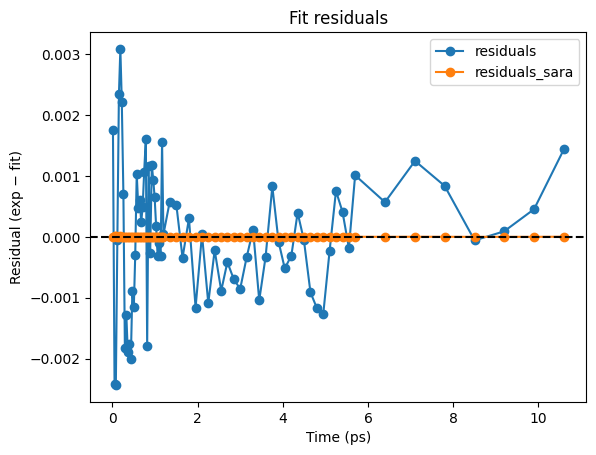

In [84]:
plt.plot(time_sara, residuals, marker='o', label='residuals')
plt.plot(time_sara, residual_s, marker='o', label='residuals_sara')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Time (ps)")
plt.ylabel("Residual (exp − fit)")
plt.title("Fit residuals")
plt.legend()
plt.show()

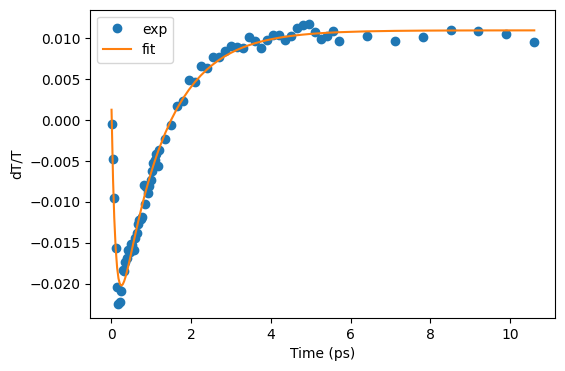

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(time_sara, y_exp, 'o', label="exp")
plt.plot(time_sara, y_fit_model, '-', label="fit")
plt.plot(time_sara, y_fit_sara, '-', label="Sara_fit")
plt.xlabel("Time (ps)")
plt.ylabel("dT/T")
plt.legend()
plt.show()